# Showcase of Girvan-Newman algorithm implementation
In the following Notebook, we showcase our implementation of the Girvan-Newman algorithm using different datasets. We will also make a performance evaluation against random graphs and make comparisons with a known library for graphs manipulation: NetworkX.
##### Authors: Kerserliss, EllynaSoumelis, Egeyae

### Imports
---

In [1]:
from girvannewman import girvannewman
from loader import load_karate, load_college_football, load_data_food_web_mat1
import matplotlib.pyplot as plt


COLORS = [
    '#1f77b4',  # Blue
    '#ff7f0e',  # Orange
    '#2ca02c',  # Green
    '#d62728',  # Red
    '#9467bd',  # Purple
    '#8c564b',  # Brown
    '#e377c2',  # Pink
    '#7f7f7f',  # Gray
    '#bcbd22',  # Yellow
    '#17becf',  # Cyan
    '#aec7e8',  # Light Blue
    '#ffbb78',  # Light Orange
    '#98df8a',  # Light Green
    '#ff9896',  # Light Red
    '#c5b0d5',  # Light Purple
    '#c49c94',  # Light Brown
    '#f7b6d2',  # Light Pink
    '#c7c7c7',  # Light Gray
    '#dbdb8d',  # Light Yellow
    '#9edae5',  # Light Cyan
]

## 1. Karate dataset
---

In the following cells, we showcase the results on the Karate dataset

[]

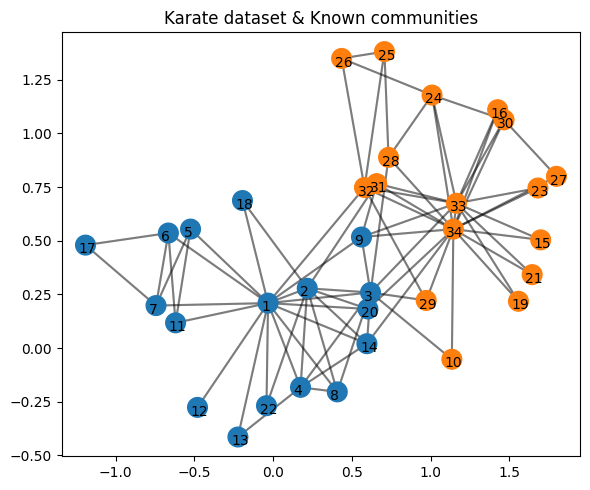

In [2]:
karate_graph, karate_known_communities = load_karate()
karate_colors = {}

for i, com in karate_known_communities.items():
    for v in com:
        karate_colors[v] = COLORS[(int(i)-1)%len(COLORS)]

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
karate_graph.plot(ax=ax, labels=True, title="Karate dataset & Known communities", colors=[karate_colors[v] for v in karate_graph.vertices])
plt.tight_layout()
plt.savefig("KnownResultsKarate.png")
plt.plot()


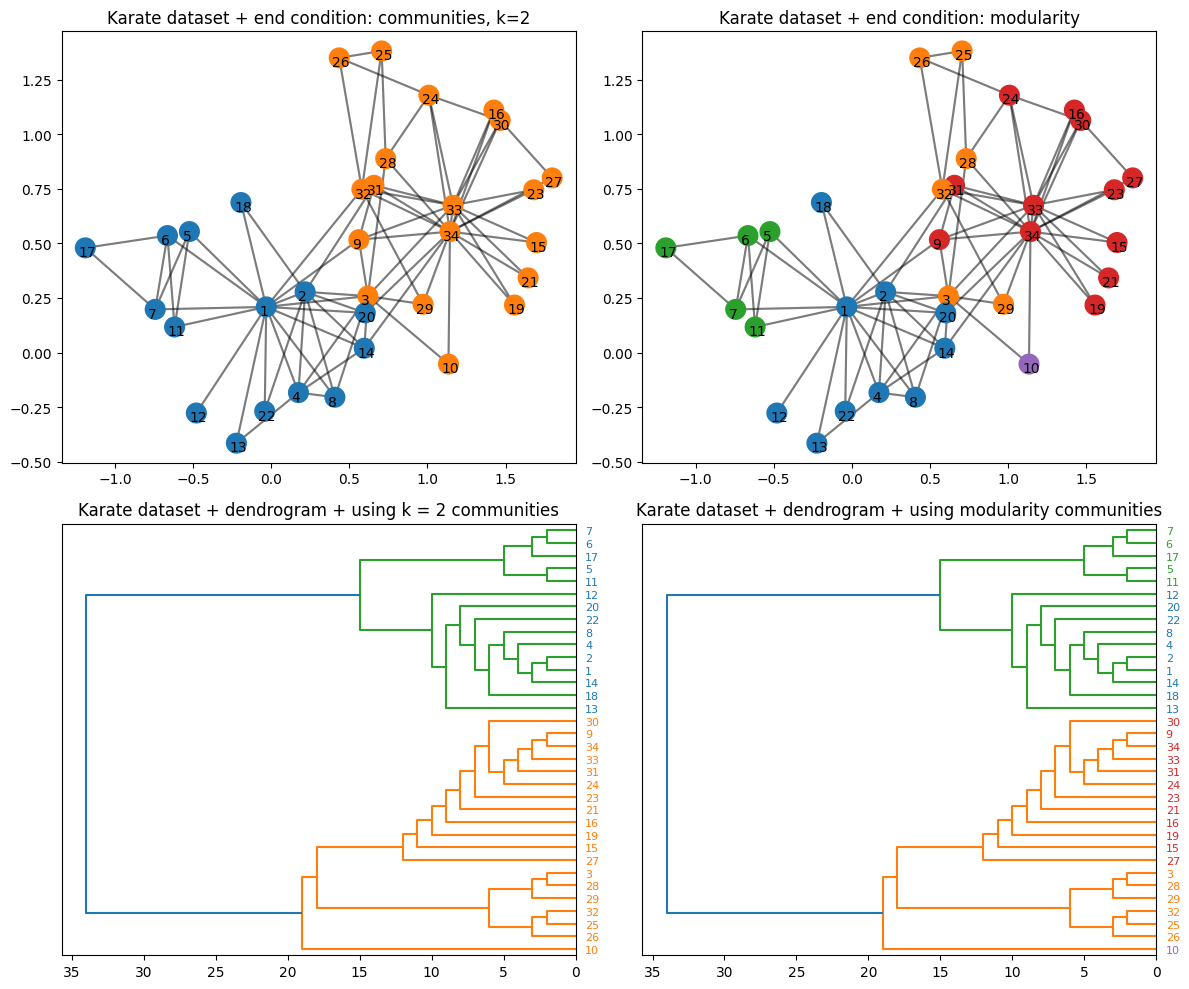

In [3]:
karate_k2_communities = girvannewman(karate_graph, method="communities", k=2)
karate_modularity_communities, _, _ = girvannewman(karate_graph, method="modularity")

k2_colors = {}
for i, com in enumerate(karate_k2_communities):
    for v in com:
        k2_colors[v] = COLORS[i%len(COLORS)]

mod_colors = {}
for i, com in enumerate(karate_modularity_communities):
    for v in com:
        mod_colors[v] = COLORS[i%len(COLORS)]
        

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))
karate_graph.plot(ax=ax1, show=False, title="Karate dataset + end condition: communities, k=2", colors=[k2_colors[v] for v in karate_graph.vertices], labels=True)
karate_graph.plot(ax=ax2, show=False, title="Karate dataset + end condition: modularity", colors=[mod_colors[v] for v in karate_graph.vertices], labels=True)
girvannewman(karate_graph, method="dendrogram", title="Karate dataset + dendrogram + using k = 2 communities", label_colors=COLORS, ax=ax3, communities=karate_k2_communities)
girvannewman(karate_graph, method="dendrogram", title="Karate dataset + dendrogram + using modularity communities", label_colors=COLORS, ax=ax4, communities=karate_modularity_communities)
plt.tight_layout()
plt.savefig("ResultsKarate.png")
plt.show()

# TODO: ANALYSIS


## 2. College football
---

In the following cells, we showcase the results on the College football dataset

[]

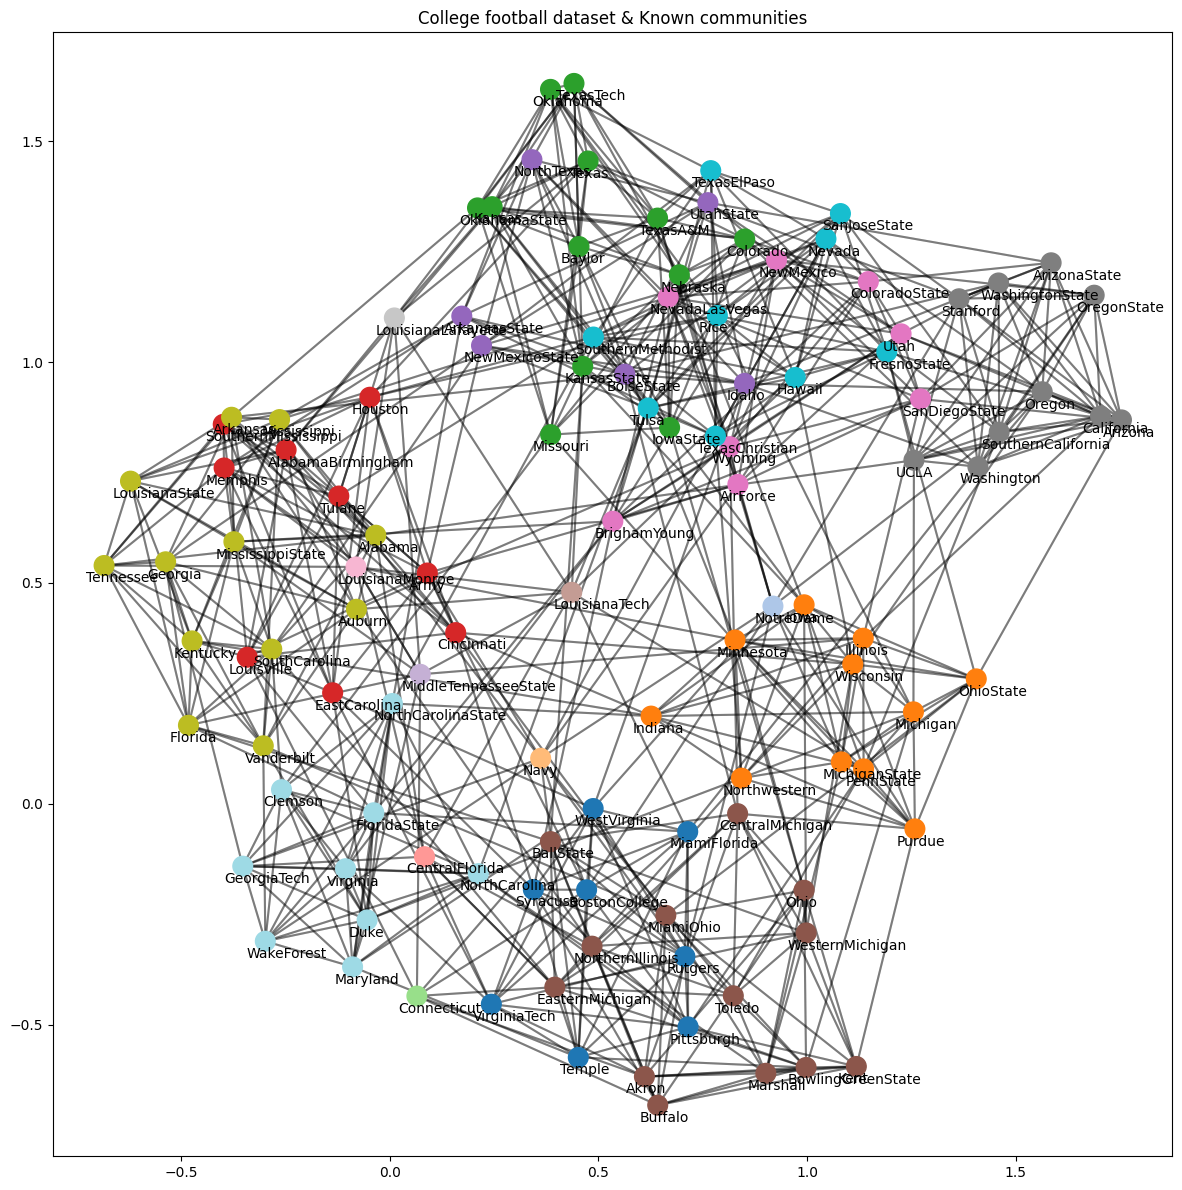

In [4]:
football_graph, football_known_communities = load_college_football()
football_colors = {}

for i, com in football_known_communities.items():
    for v in com:
        football_colors[v] = COLORS[(int(i)-1)%len(COLORS)]

fig, ax = plt.subplots(1, 1, figsize=(12, 12))
football_graph.plot(k=500, labels=True, title="College football dataset & Known communities", colors=[football_colors[v] for v in football_graph.vertices], ax=ax, desired=0.1, repulsion=0.3, attraction=0.4)
plt.tight_layout()
plt.savefig("KnownResultsCollegeFootball.png")
plt.plot()

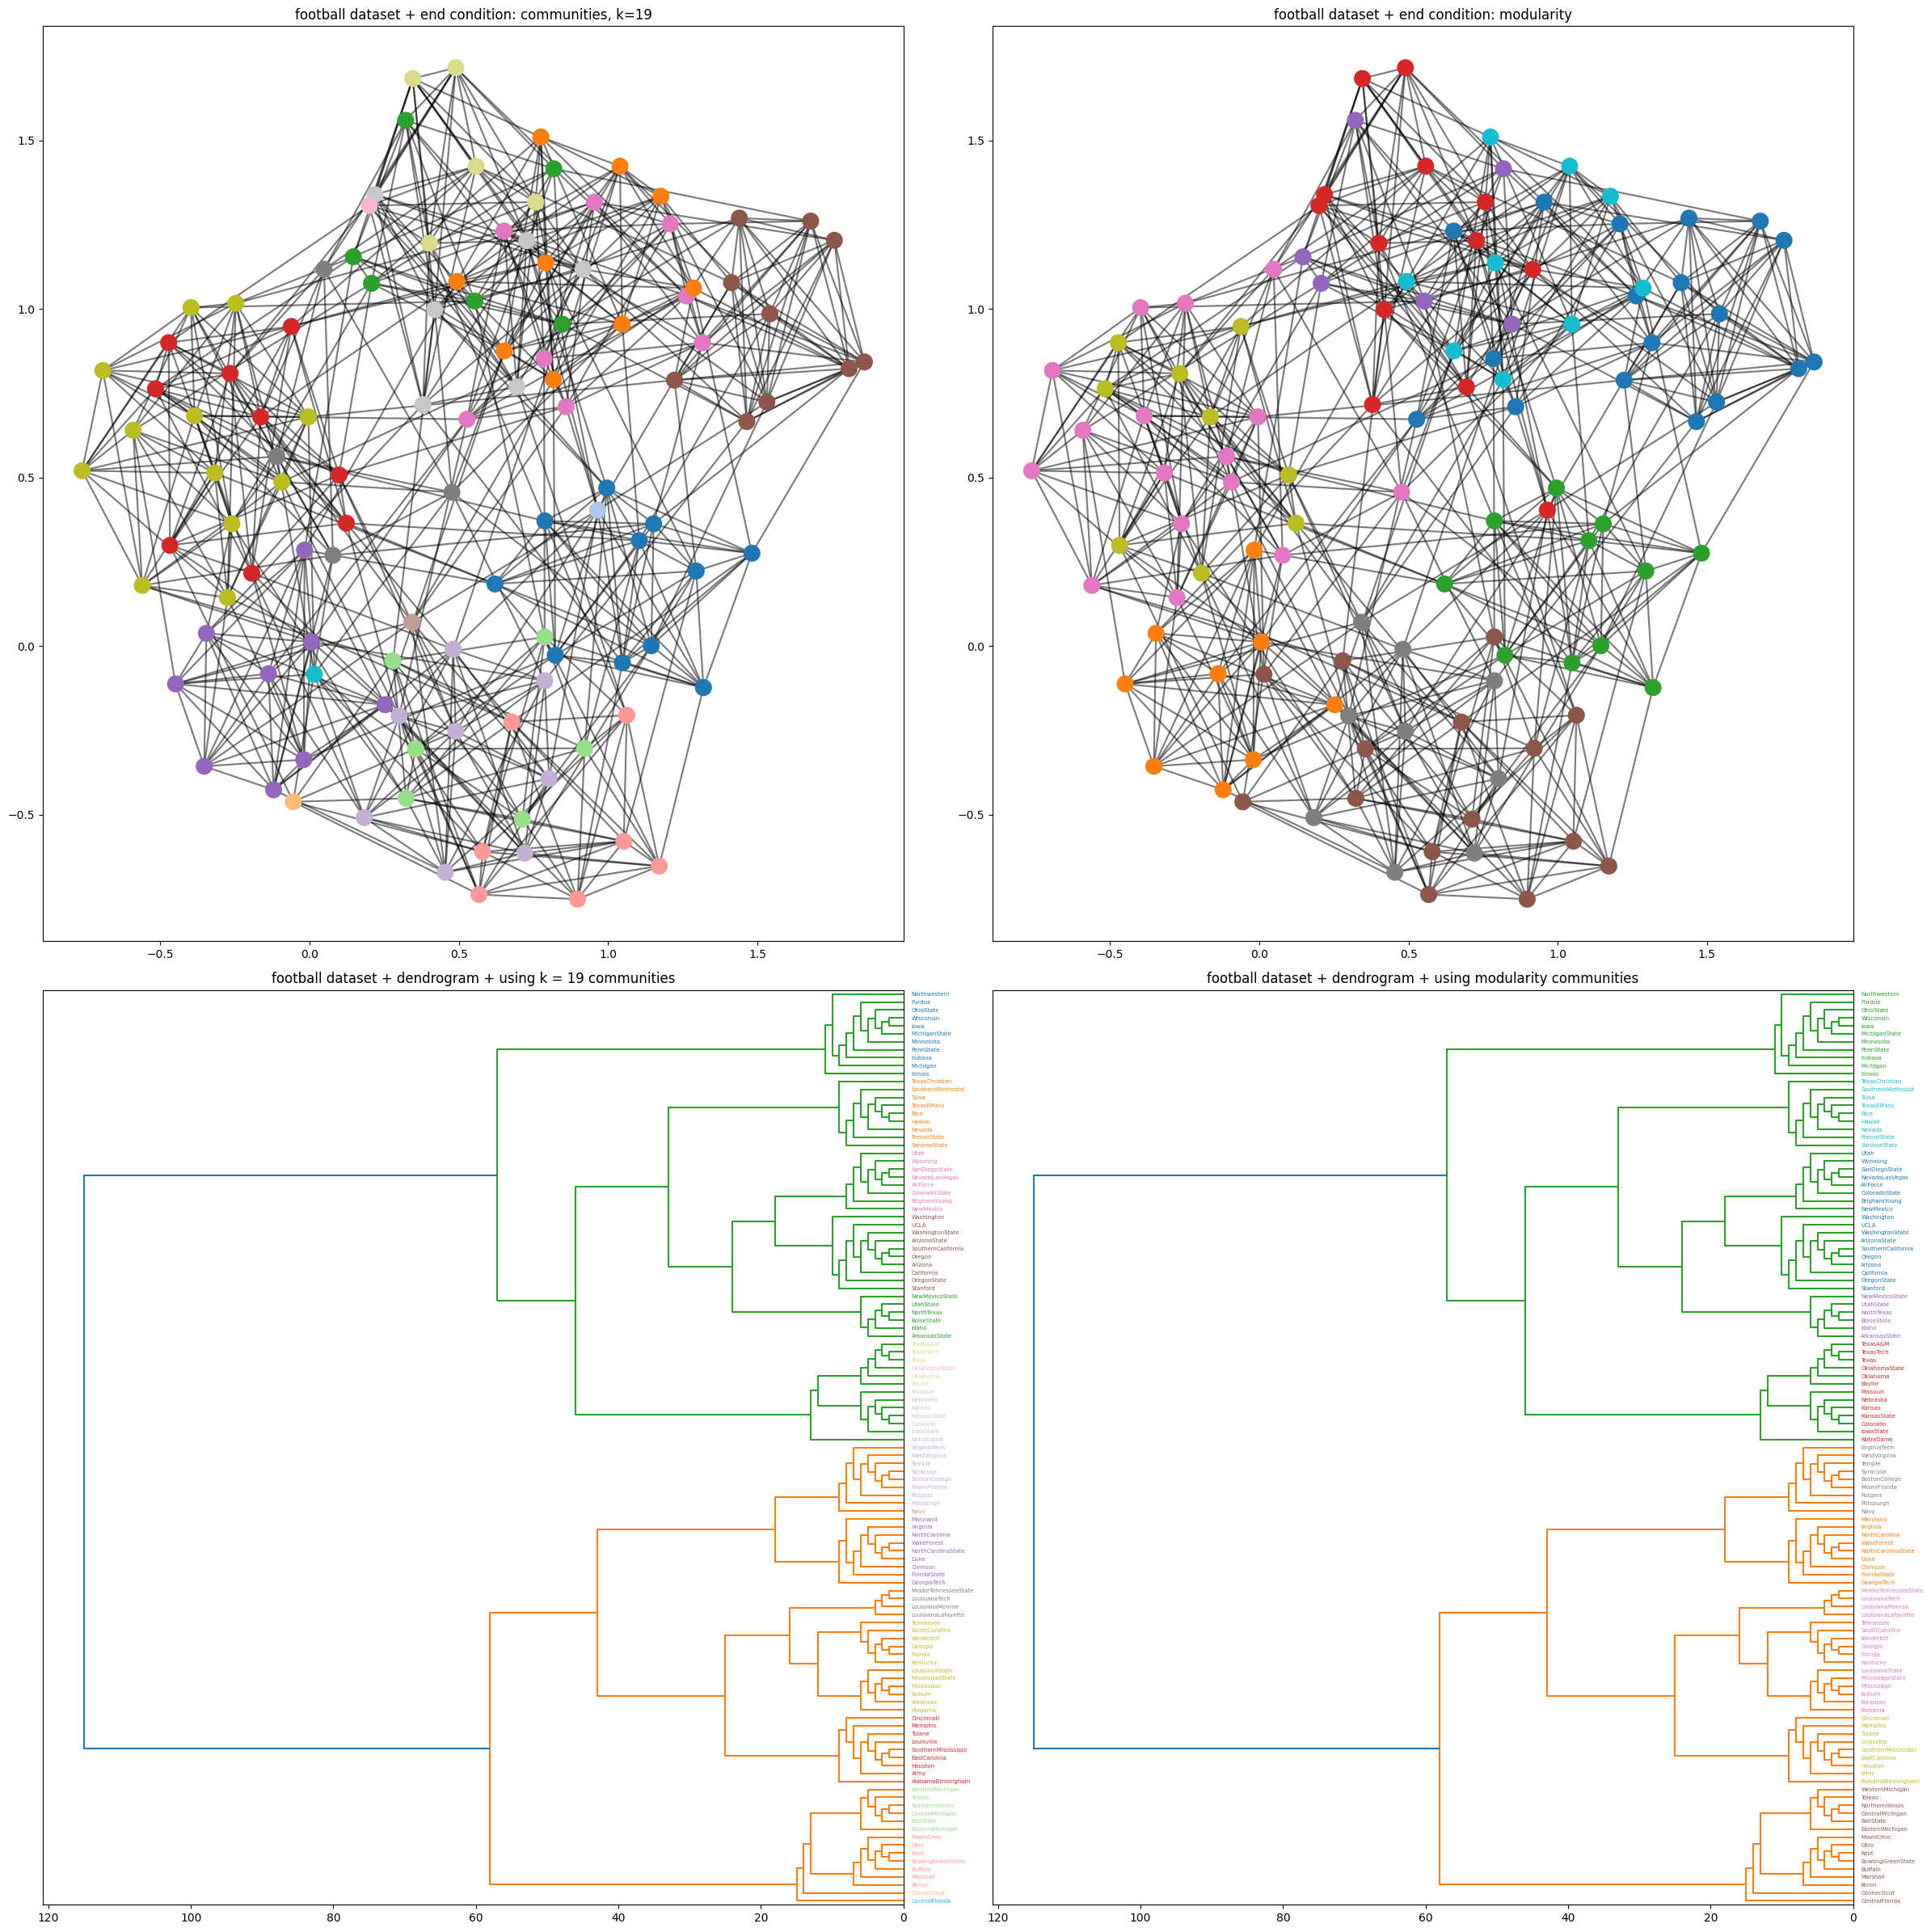

In [5]:
football_k2_communities = girvannewman(football_graph, method="communities", k=19)
football_modularity_communities, _, _ = girvannewman(football_graph, method="modularity")

k2_colors = {}
for i, com in enumerate(football_k2_communities):
    for v in com:
        k2_colors[v] = COLORS[i%len(COLORS)]

mod_colors = {}
for i, com in enumerate(football_modularity_communities):
    for v in com:
        mod_colors[v] = COLORS[i%len(COLORS)]
        

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(24, 24))
football_graph.plot(k=300, ax=ax1, show=False, title="football dataset + end condition: communities, k=19", colors=[k2_colors[v] for v in football_graph.vertices], labels=False)
football_graph.plot(k=300, ax=ax2, show=False, title="football dataset + end condition: modularity", colors=[mod_colors[v] for v in football_graph.vertices], labels=False)
girvannewman(football_graph, method="dendrogram", title="football dataset + dendrogram + using k = 19 communities", label_colors=COLORS, ax=ax3, communities=football_k2_communities)
girvannewman(football_graph, method="dendrogram", title="football dataset + dendrogram + using modularity communities", label_colors=COLORS, ax=ax4, communities=football_modularity_communities)
plt.tight_layout()
plt.savefig("ResultsCollegeFootball.png")
plt.show()

[]

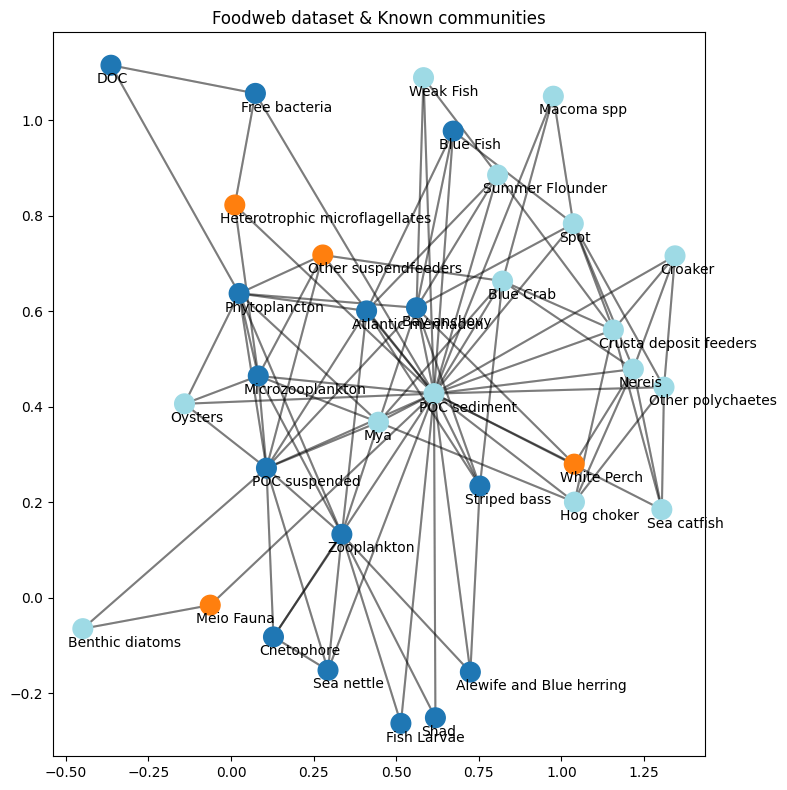

In [6]:
foodweb_mat1_graph, foodweb_known_communities = load_data_food_web_mat1()
foodweb_colors = {}

for i, com in foodweb_known_communities.items():
    for v in com:
        foodweb_colors[v] = COLORS[(int(i)-1)%len(COLORS)]

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
foodweb_mat1_graph.plot(k=500, labels=True, title="Foodweb dataset & Known communities", colors=[foodweb_colors[v] for v in foodweb_mat1_graph.vertices], ax=ax, desired=0.1, repulsion=0.3, attraction=0.4)
plt.tight_layout()
plt.savefig("KnownResultsFoodweb.png")
plt.plot()


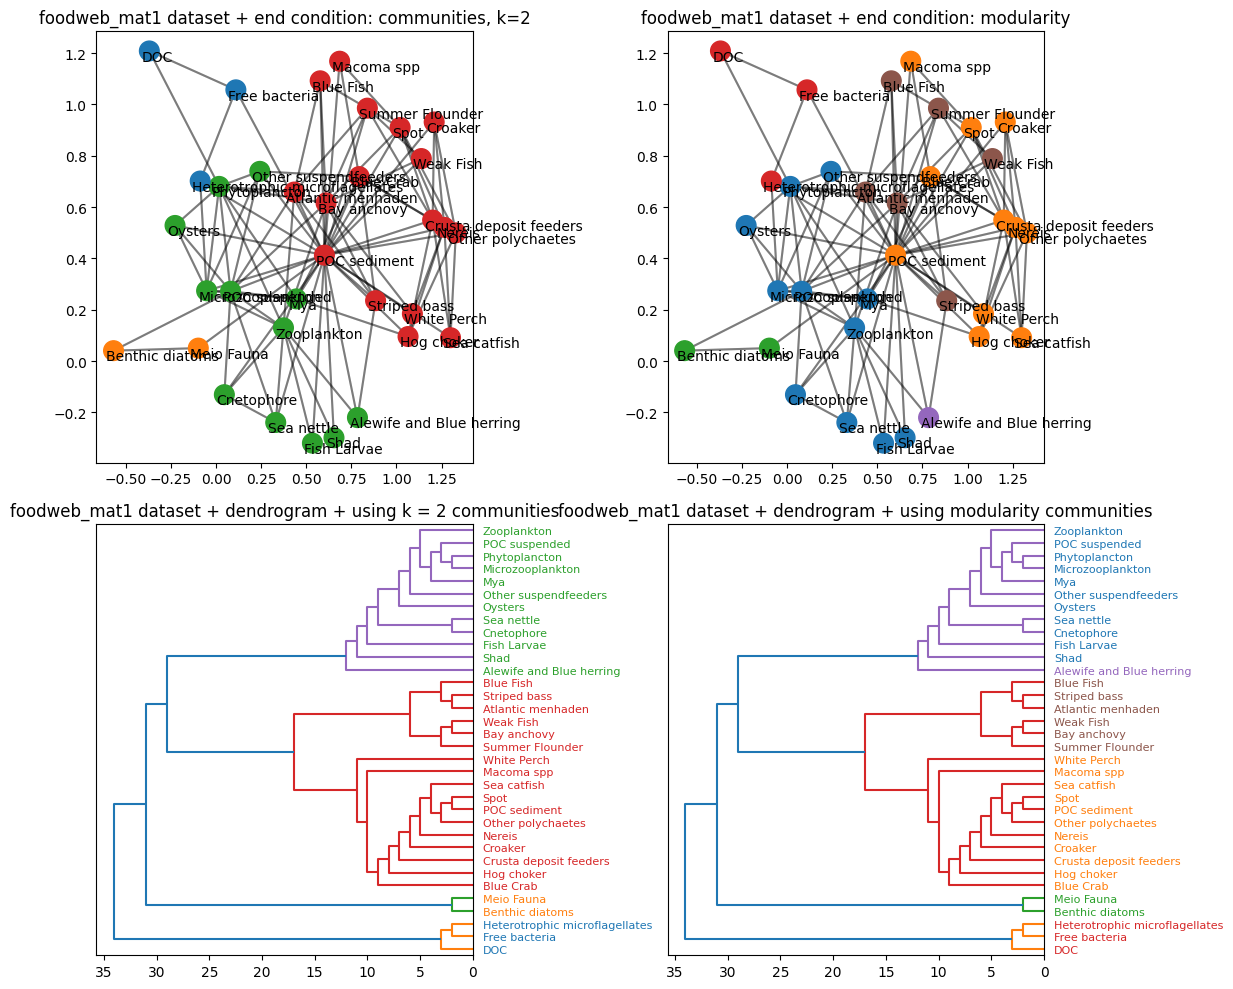

In [7]:
foodweb_mat1_k2_communities = girvannewman(foodweb_mat1_graph, method="communities", k=4)
foodweb_mat1_modularity_communities, _, _ = girvannewman(foodweb_mat1_graph, method="modularity")

k2_colors = {}
for i, com in enumerate(foodweb_mat1_k2_communities):
    for v in com:
        k2_colors[v] = COLORS[i%len(COLORS)]

mod_colors = {}
for i, com in enumerate(foodweb_mat1_modularity_communities):
    for v in com:
        mod_colors[v] = COLORS[i%len(COLORS)]


fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))
foodweb_mat1_graph.plot(ax=ax1, show=False, title="foodweb_mat1 dataset + end condition: communities, k=2", colors=[k2_colors[v] for v in foodweb_mat1_graph.vertices], labels=True)
foodweb_mat1_graph.plot(ax=ax2, show=False, title="foodweb_mat1 dataset + end condition: modularity", colors=[mod_colors[v] for v in foodweb_mat1_graph.vertices], labels=True)
girvannewman(foodweb_mat1_graph, method="dendrogram", title="foodweb_mat1 dataset + dendrogram + using k = 2 communities", label_colors=COLORS, ax=ax3, communities=foodweb_mat1_k2_communities)
girvannewman(foodweb_mat1_graph, method="dendrogram", title="foodweb_mat1 dataset + dendrogram + using modularity communities", label_colors=COLORS, ax=ax4, communities=foodweb_mat1_modularity_communities)
plt.tight_layout()
plt.savefig("ResultsFoodWebMat1.png")
plt.show()

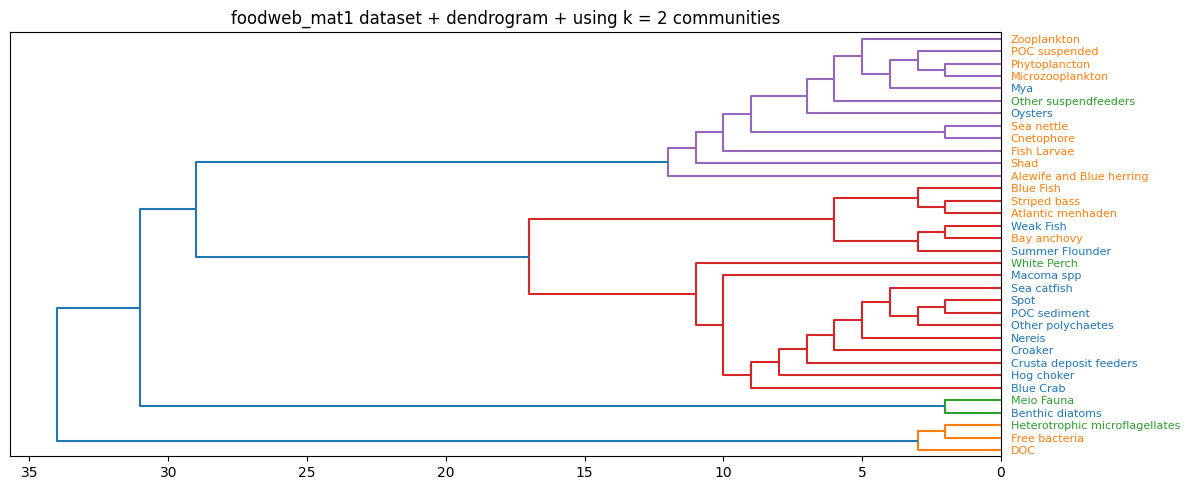

In [8]:
fig, ax1 = plt.subplots(1, 1, figsize=(12, 5))
girvannewman(foodweb_mat1_graph, method="dendrogram", title="foodweb_mat1 dataset + dendrogram + using k = 2 communities", label_colors=COLORS, ax=ax1, communities=[x for x in foodweb_known_communities.values()])
plt.tight_layout()
plt.savefig("ResultsFoodWebMat1_with_KnownLabels.png")
plt.show()